# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import * 
from core.dgp import *

import core.binary_treatment_multiple_segments as btms

# DGP

In [6]:
dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 1.0, 
}

dgp = MultipleSegments(**dgp_params)

In [7]:
segment_arr, treatment_arr, outcome_arr = dgp.sample(600, seed=0)

# Demand Model

In [8]:
te_est_arr = btms.segment_difference_in_mean(segment_arr, treatment_arr, outcome_arr)

for segment in dgp.segment_arr:
    print(f'Segment {segment}: True TE: {dgp.segment_te_arr[segment]:.2f}, Estimated TE: {te_est_arr[segment]:.2f}')

Segment 0: True TE: 0.05, Estimated TE: 0.05
Segment 1: True TE: 0.10, Estimated TE: 0.06


# Optimization

In [9]:
# sample customers to target
targ_customers = dgp.sample_individuals(100, seed=10)

# optimize the targeting strategy
plugin_decision, plugin_val_est = btms.optimize(
    targ_customers, te_est_arr, 10
)

# calculate the value of the objective function
true_plugin_val = btms.obj_func(
    targ_customers, dgp.segment_te_arr, plugin_decision
)

print('Estimated plugin policy value:', plugin_val_est)
print('True plugin policy value:', true_plugin_val)

Estimated plugin policy value: 0.6193793558496603
True plugin policy value: 1.0


# Winner's Curse

In [10]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 1.0, 
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {'n_experiments': 1000}

estimators_dict = {}

result_records = btms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    verbose=False, n_jobs=-1
)

wc_measures_dict = btms.calculate_winners_curse_measures(
    result_records=result_records, operations_params=operations_params, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")
print(f"Average Winner's Curse Percentage of True Value: {100 * wc_measures_dict['nc_wc_pct_avg']:.2f}% ({100 * wc_measures_dict['nc_wc_pct_se']:.2f}%)")
print(f"Average Overestimated ROI: {100 * wc_measures_dict['nc_over_roi_avg']:.2f}% ({100 * wc_measures_dict['nc_over_roi_se']:.2f}%)")

print(f"\nRMSE={wc_measures_dict['nc_wc_rmse']:.4f}")

Average Winner's Curse: 0.6748 (0.0453)
Average Winner's Curse Percentage of True Value: 99.11% (6.93%)
Average Overestimated ROI: 6.75% (0.45%)

RMSE=1.2178


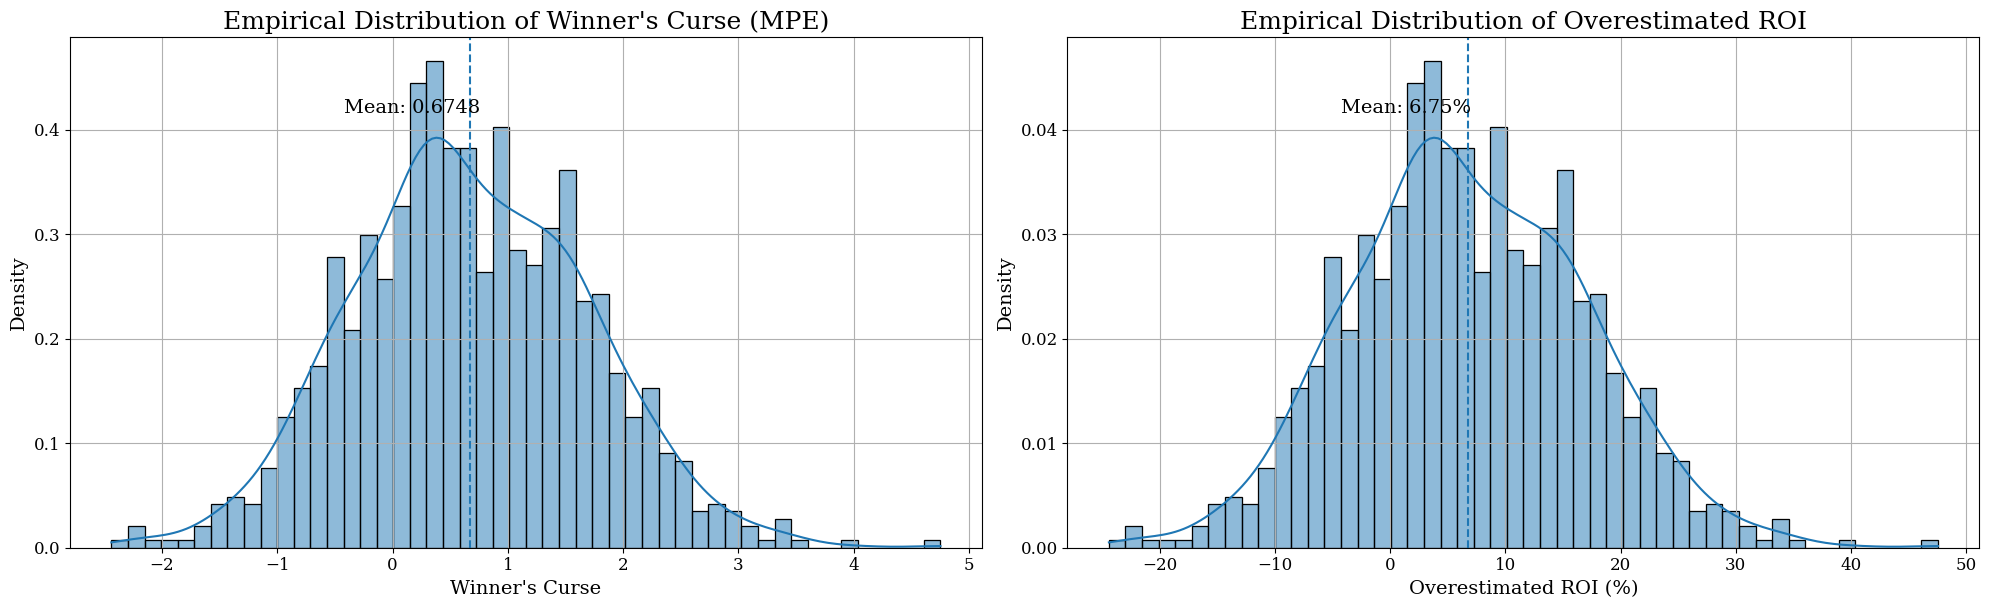

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=axes[0], color='C0')
axes[0].axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')
axes[0].annotate(
    f"Mean: {wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.3, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[0].set_title("Empirical Distribution of Winner's Curse (MPE)", fontsize=title_size)

axes[0].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[0].set_xlabel("Winner's Curse", fontsize=axis_label_size)
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].grid()

sns.histplot(100 * wc_measures_dict['nc_over_roi_arr'], bins=50, kde=True, stat='density', ax=axes[1], color='C0')
axes[1].axvline(100 * wc_measures_dict['nc_over_roi_avg'], color='C0', linestyle='--')
axes[1].annotate(
    f"Mean: {100 * wc_measures_dict['nc_over_roi_avg']:.2f}%", 
    xy=(0.3, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
axes[1].set_title("Empirical Distribution of Overestimated ROI", fontsize=title_size)
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[1].set_xlabel("Overestimated ROI (%)", fontsize=axis_label_size)
axes[1].set_ylabel('Density', fontsize=axis_label_size)
axes[1].grid()

plt.tight_layout()
plt.savefig('figures/case2-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [12]:
dgp = MultipleSegments(**dgp_params)
segment_arr, treatment_arr, outcome_arr = dgp.sample(data_params['sample_size'], seed=0)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=1)

## Standard Bootstrap

In [13]:
boot_wc_dstn_arr = btms.get_wc_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.0s finished


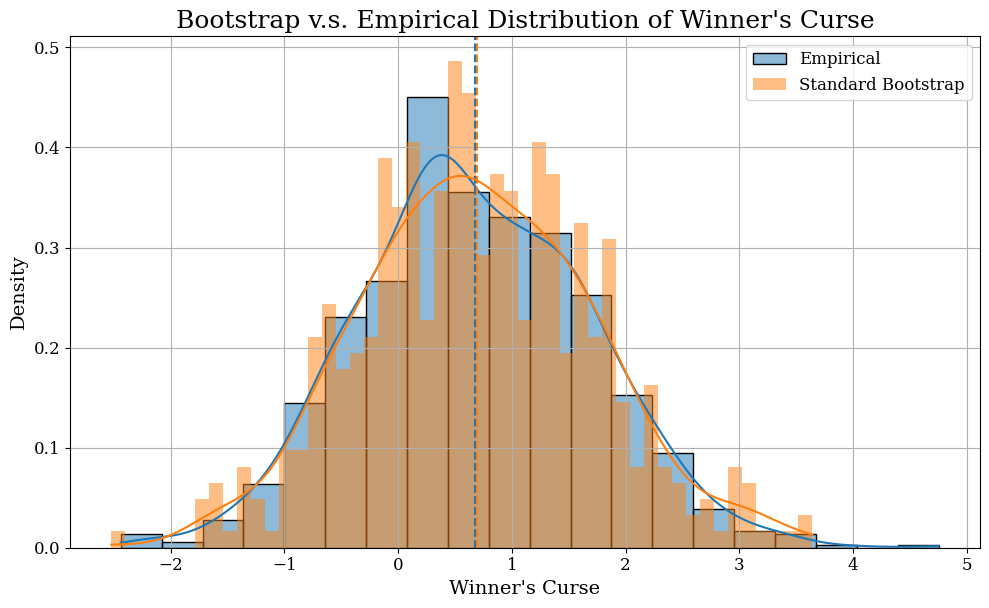

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap', edgecolor=None)
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [15]:
mn_boot_wc_dstn_arr = btms.get_wc_m_out_of_n_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, power=0.95, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.0s finished


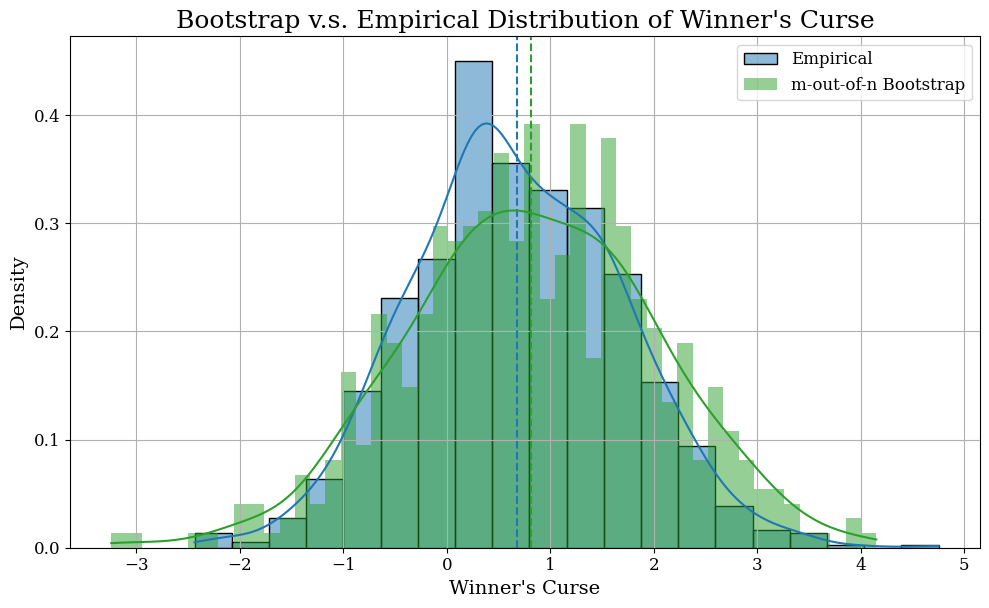

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap', edgecolor=None)
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [17]:
num_boot_wc_dstn_arr = btms.get_wc_num_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, power=-0.45, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


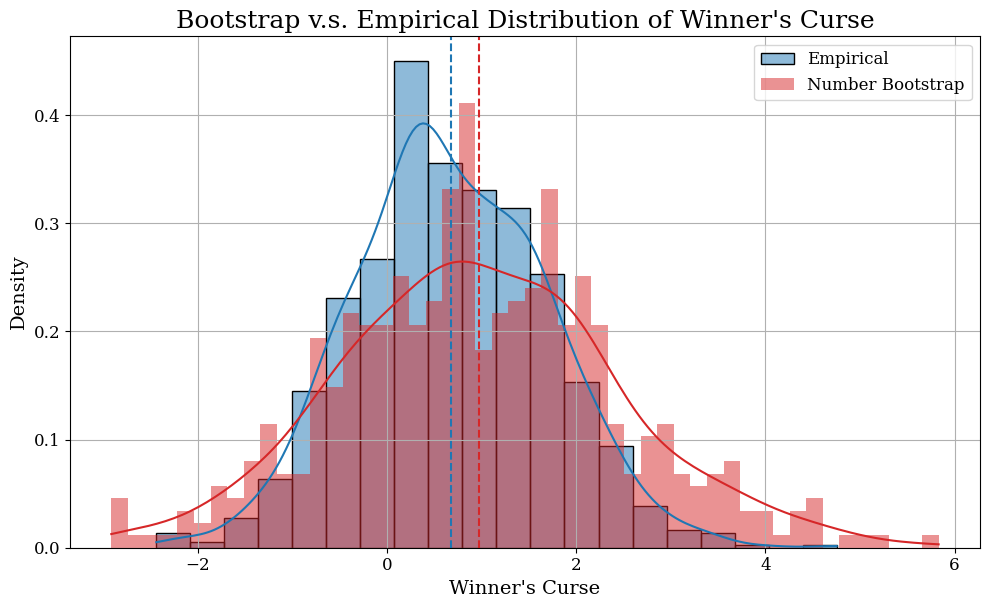

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Number Bootstrap', edgecolor=None)
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [19]:
del dgp, segment_arr, treatment_arr, outcome_arr, targ_customers
del wc_measures_dict, boot_wc_dstn_arr, mn_boot_wc_dstn_arr, num_boot_wc_dstn_arr

# Bias Correction

In [15]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 5, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 1.0, 
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': btms.sample_splitting_estimate, 
        'params': {}, 
    }, 
    'empirical_bayes': {
        'estimator': btms.empirical_bayes_estimate, 
        'params': {'n_degree': 5, 'n_knots': 2, 'bin_width': 0.1, 'smoothing': 0.5}
    }, 
    'normal_prior_bayes': {
        'estimator': btms.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}
    }, 
    'standard_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 600, 'bootstrap_method': 'standard', 'n_jobs': 1, }
    }, 
    'mn_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1, 
        }
    }, 
    'num_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1, 
        }
    }
}

In [16]:
result_records = btms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = btms.calculate_winners_curse_measures(
    result_records=result_records, operations_params=operations_params, 
    estimators_dict=estimators_dict, data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   28.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   37.9s finished


In [17]:
for estimator in ['nc'] + list(estimators_dict.keys()):
    print(f"\nWinner's Curse of {estimator}: {wc_measures_dict[f'{estimator}_wc_avg']:.4f} ({wc_measures_dict[f'{estimator}_wc_se']:.4f})", end=', ')
    print(f"Percentage of True Value: {100 * wc_measures_dict[f'{estimator}_wc_pct_avg']:.2f}% ({100 * wc_measures_dict[f'{estimator}_wc_pct_se']:.2f}%)", end=', ')
    print(f"RMSE={wc_measures_dict[f'{estimator}_wc_rmse']:.4f}")

    print(f"Overestiamted ROI of {estimator}: {100 * wc_measures_dict[f'{estimator}_over_roi_avg']:.2f}% ({100 * wc_measures_dict[f'{estimator}_over_roi_se']:.2f}%)")


Winner's Curse of nc: 2.2512 (0.0645), Percentage of True Value: 164.35% (7.92%), RMSE=2.6730
Overestiamted ROI of nc: 22.51% (0.64%)

Winner's Curse of sample_splitting: 0.1228 (0.1303), Percentage of True Value: 14.36% (11.26%), RMSE=2.9164
Overestiamted ROI of sample_splitting: 1.23% (1.30%)

Winner's Curse of empirical_bayes: 2.3022 (0.1052), Percentage of True Value: 163.35% (9.67%), RMSE=3.2914
Overestiamted ROI of empirical_bayes: 23.02% (1.05%)

Winner's Curse of normal_prior_bayes: 2.2084 (0.0638), Percentage of True Value: 161.61% (7.83%), RMSE=2.6290
Overestiamted ROI of normal_prior_bayes: 22.08% (0.64%)

Winner's Curse of standard_bootstrap: 0.7067 (0.0774), Percentage of True Value: 58.39% (6.32%), RMSE=1.8696
Overestiamted ROI of standard_bootstrap: 7.07% (0.77%)

Winner's Curse of mn_bootstrap: 0.2937 (0.0777), Percentage of True Value: 31.02% (5.98%), RMSE=1.7622
Overestiamted ROI of mn_bootstrap: 2.94% (0.78%)

Winner's Curse of num_bootstrap: 0.1437 (0.0829), Percen

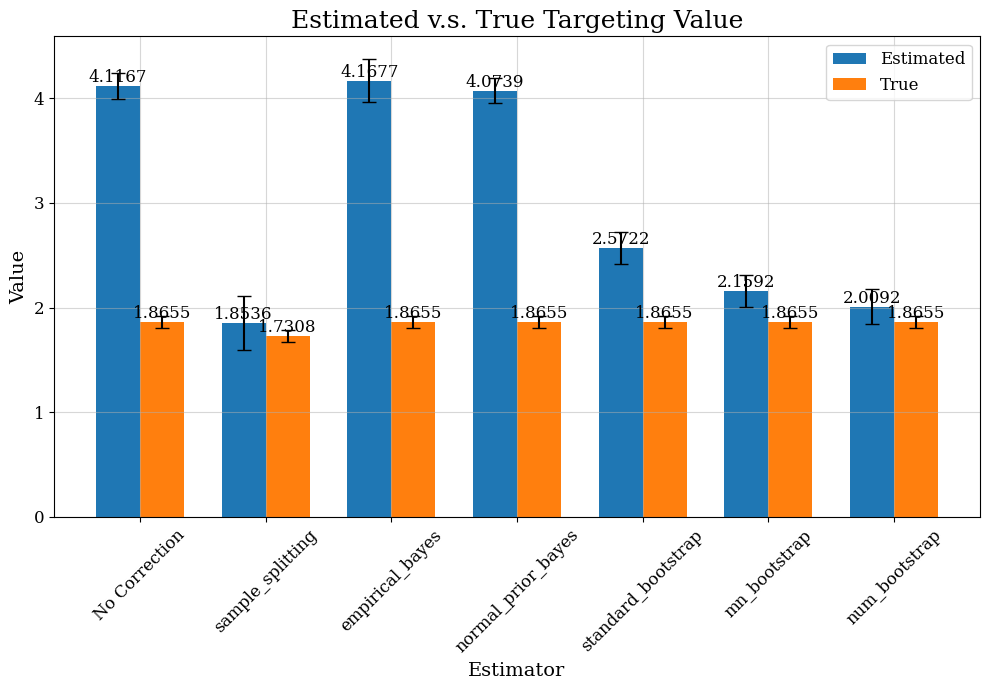

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(estimators_dict) + 1)
width = 0.35

ax.bar(
    x - width/2, 
    height=[wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='Estimated', color='C0'
)

ax.bar(
    x + width/2, 
    height=[wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_true_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='True', color='C1'
)

# add text annotation
for i, (val_est, val_true) in enumerate(zip(
    [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    [wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())]
)):
    ax.text(
        i - width/2, val_est, f"{val_est:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size
    )
    ax.text(
        i + width/2, val_true, f"{val_true:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size
    )

ax.set_title("Estimated v.s. True Targeting Value", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(x)
ax.set_xticklabels(['No Correction'] + list(estimators_dict.keys()), rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['Estimated', 'True'], fontsize=legend_label_size)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

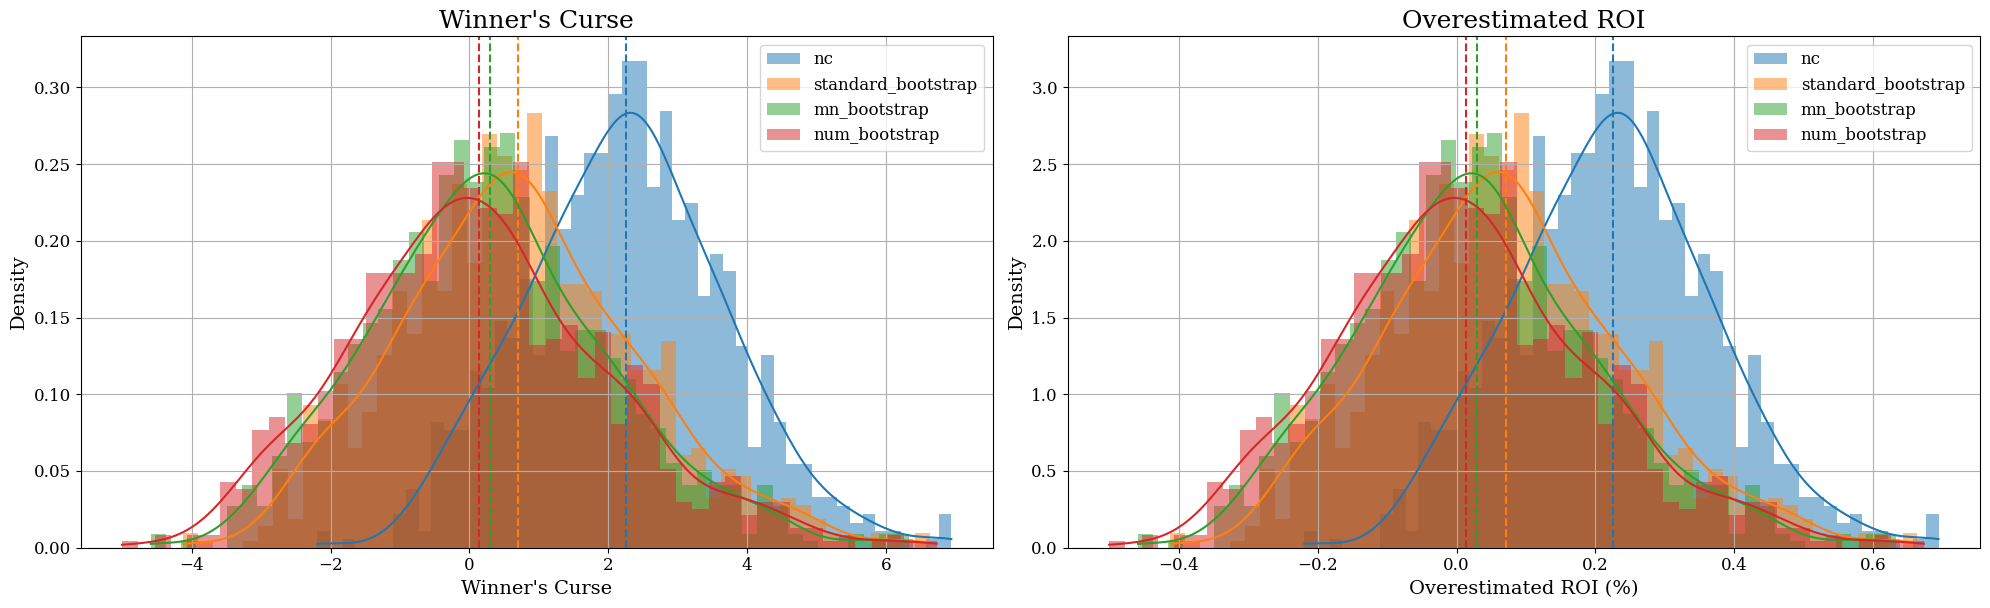

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(wc_measures_dict[f"{estimator}_wc_arr"], bins=50, kde=True, stat='density', ax=axes[0], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[0].axvline(wc_measures_dict[f"{estimator}_wc_avg"], color=f'C{idx}', linestyle='--')

axes[0].set_title('Winner\'s Curse', fontsize=title_size)
axes[0].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)

# overestimated ROI
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(wc_measures_dict[f"{estimator}_over_roi_arr"], bins=50, kde=True, stat='density', ax=axes[1], color=f'C{idx}', edgecolor=None, label=estimator)
    axes[1].axvline(wc_measures_dict[f"{estimator}_over_roi_avg"], color=f'C{idx}', linestyle='--')

axes[1].set_title('Overestimated ROI', fontsize=title_size)
axes[1].set_xlabel('Overestimated ROI (%)', fontsize=axis_label_size)

for ax in axes:
    ax.tick_params(labelsize=tick_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.set_ylabel('Density', fontsize=axis_label_size)
    ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

# Sensitivity Analysis

## Sample Size

In [8]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 3.0, 
}

data_params = {'sample_size': np.nan, 'n_customers': 100}

experiment_params = {'n_experiments': 10000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1, }
    }, 
    'mn_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1, 
        }
    }, 
    'num_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1, 
        }
    }
}

In [9]:
sample_size_result_dict = btms.sample_size_test(
    sample_sizes=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000],
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case3_sample_size_test.pkl'
)


Running sample size 100 (1/14)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   36.4s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:   47.4s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 5986 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 7136 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 8386 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 9736 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  2.5min finished
[Parallel(n_jobs=-1)]: Using bac

Finished sample size 100 in 0:02:32.910852

Running sample size 200 (2/14)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   29.7s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   40.4s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:   52.8s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 5986 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 7136 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 8386 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 9736 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  2.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished sample size 200 in 0:02:45.075019

Running sample size 300 (3/14)
Running 10000 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   28.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   53.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  5.8min
[Parallel(n_jobs=-1)]: Done 5986 tasks      | elapsed:  7.0min
[Parallel(n_jobs=-1)]: Done 7136 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 8386 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 9736 tasks      | elapsed: 11.4min
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed: 11.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished sample size 4000 in 0:11:39.202277

Running sample size 5000 (14/14)
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   33.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  7.0min
[Parallel(n_jobs=-1)]: Done 5986 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 7136 tasks      | elapsed: 10.1min
[Parallel(n_jobs=-1)]: Done 8386 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-1)]: Done 9736 tasks      | elapsed: 13.8min


Finished sample size 5000 in 0:14:08.040002


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed: 14.1min finished


In [17]:
with open('results/case3_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

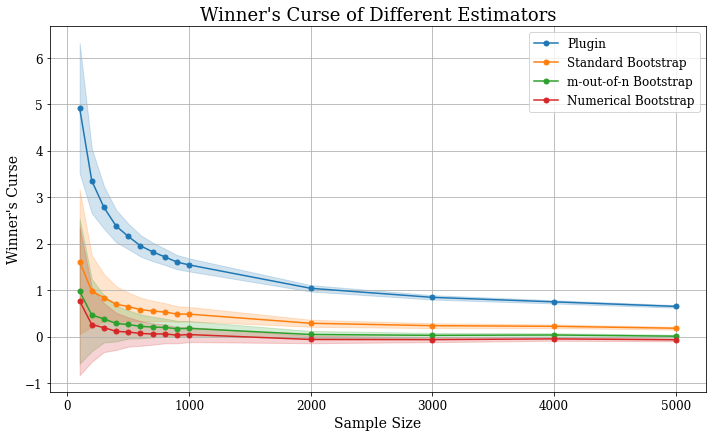

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_mean'] - 1.96 * result_df['plugin_wc_se'],
    result_df['plugin_wc_mean'] + 1.96 * result_df['plugin_wc_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_wc_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['stand_bootstrap_wc_mean'] - 1.96 * result_df['stand_bootstrap_wc_se'],
    result_df['stand_bootstrap_wc_mean'] + 1.96 * result_df['stand_bootstrap_wc_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_mean'] - 1.96 * result_df['mn_bootstrap_wc_se'], 
    result_df['mn_bootstrap_wc_mean'] + 1.96 * result_df['mn_bootstrap_wc_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_mean'] - 1.96 * result_df['num_bootstrap_wc_se'], 
    result_df['num_bootstrap_wc_mean'] + 1.96 * result_df['num_bootstrap_wc_se'], 
    color='C3', alpha=0.2
)


ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case3-sample-size-test.png')
plt.show()

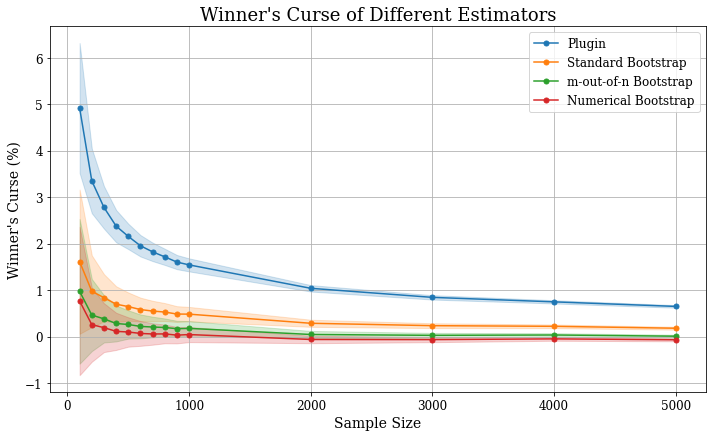

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_pct_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_pct_mean'] - 1.96 * result_df['plugin_wc_pct_se'],
    result_df['plugin_wc_pct_mean'] + 1.96 * result_df['plugin_wc_pct_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['stand_bootstrap_wc_pct_mean'] - 1.96 * result_df['stand_bootstrap_wc_pct_se'],
    result_df['stand_bootstrap_wc_pct_mean'] + 1.96 * result_df['stand_bootstrap_wc_pct_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_pct_mean'] - 1.96 * result_df['mn_bootstrap_wc_pct_se'], 
    result_df['mn_bootstrap_wc_pct_mean'] + 1.96 * result_df['mn_bootstrap_wc_pct_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_pct_mean'] - 1.96 * result_df['num_bootstrap_wc_pct_se'], 
    result_df['num_bootstrap_wc_pct_mean'] + 1.96 * result_df['num_bootstrap_wc_pct_se'], 
    color='C3', alpha=0.2
)

ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case3-sample-size-test.png')
plt.show()